# Eigen-vibrations: detecting structural damage with linear algebra

**Course:** UE25MA242A, Mathematics for AI & Data (mini project)

**Idea in one line:** learn what *healthy* vibration looks like from a steel structure's sensors, then flag any new vibration that the healthy patterns cannot explain.

**Data:** Qatar University Grandstand Simulator (QUGS) benchmark. A steel frame with 30 accelerometers (one per joint), shaken by a white-noise shaker, 1024 readings per second for 256 s. Damage = bolts loosened at one joint.

| File | Role |
|---|---|
| `zzzAU.TXT` | Healthy, run A: **learn** "normal" from this |
| `zzzBU.TXT` | Healthy, run B: **unseen healthy test** |
| `zzzBD3.TXT`, `zzzBD13.TXT`, `zzzBD26.TXT` | Run B with damage at joint 3, 13, 26: **unseen damaged tests** |

> Data source: Avci, O., Abdeljaber, O., Kiranyaz, S., Hussein, M., Gabbouj, M., Inman, D. (2022). *A New Benchmark Problem for Structural Damage Detection: Bolt Loosening Tests on a Large-Scale Laboratory Structure.* Dynamics of Civil Structures, Vol. 2, Springer.

**Workflow (from the project guidelines):**
Real-world data → Matrix representation → Matrix simplification (RREF) → Structure of the space (rank, nullity, basis) → Remove redundancy (basis selection) → Orthogonalization (Gram–Schmidt) → Projection → Least squares → Eigenvalues/eigenvectors → Diagonalization → Final output (damage detection)

Part A walks through every step on a tiny matrix you can check by hand. Part B applies the same steps to the real sensor data.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import sympy as sp
from pathlib import Path

np.set_printoptions(precision=3, suppress=True, linewidth=120)
FIG = Path("figures"); FIG.mkdir(exist_ok=True)

# Chart colours: blue = healthy, orange = damaged, grey = reference lines
BLUE, ORANGE, GREY = "#2a78d6", "#eb6834", "#888780"
plt.rcParams.update({
    "figure.dpi": 110, "axes.spines.top": False, "axes.spines.right": False,
    "axes.grid": True, "grid.alpha": 0.25, "grid.linewidth": 0.6,
    "axes.titlesize": 12, "axes.labelsize": 10, "lines.linewidth": 2,
})

---
# Part A: the whole method on a tiny example

Four healthy "fingerprints", each describing one second of shaking by how strong three speeds are (low, mid, high). Small enough to check by hand.

In [2]:
H = sp.Matrix([[4, 2, 1],
               [6, 3, 1],
               [2, 1, 1],
               [8, 4, 1]])
mean = sp.Matrix([[sum(H[:, c]) / H.rows for c in range(H.cols)]])
X = H - sp.ones(H.rows, 1) * mean          # subtract the average row
print("Healthy matrix H (rows = seconds, columns = low/mid/high):"); sp.pprint(H)
print("\nAverage row:", list(mean))
print("\nCentred matrix X = H - average:"); sp.pprint(X)

Healthy matrix H (rows = seconds, columns = low/mid/high):
⎡4  2  1⎤
⎢       ⎥
⎢6  3  1⎥
⎢       ⎥
⎢2  1  1⎥
⎢       ⎥
⎣8  4  1⎦

Average row: [5, 5/2, 1]

Centred matrix X = H - average:
⎡-1  -1/2  0⎤
⎢           ⎥
⎢1   1/2   0⎥
⎢           ⎥
⎢-3  -3/2  0⎥
⎢           ⎥
⎣3   3/2   0⎦


**Matrix simplification (RREF) and structure of the space.** RREF shows how many rows are genuinely independent.

In [3]:
R, pivots = X.rref()
print("RREF(X):"); sp.pprint(R)
print(f"\nPivot columns: {pivots}")
print(f"Rank = {X.rank()}, Nullity = {X.cols - X.rank()}  (rank + nullity = {X.cols} columns)")
print("Row-space basis:", list(R[0, :]))
print("Meaning: healthy variation happens along ONE direction only.")

RREF(X):
⎡1  1/2  0⎤
⎢         ⎥
⎢0   0   0⎥
⎢         ⎥
⎢0   0   0⎥
⎢         ⎥
⎣0   0   0⎦

Pivot columns: (0,)
Rank = 1, Nullity = 2  (rank + nullity = 3 columns)
Row-space basis: [1, 1/2, 0]
Meaning: healthy variation happens along ONE direction only.


**Orthogonalization (Gram–Schmidt).** Turn any set of independent vectors into perpendicular unit vectors.

In [4]:
def gram_schmidt(vectors):
    basis = []
    for v in vectors:
        w = v - sum(((v.dot(b)) * b for b in basis), sp.zeros(*v.shape))
        if w.norm() != 0:
            basis.append(w / w.norm())
    return basis

q = gram_schmidt([X[r, :].T for r in range(X.rows)])
print(f"Gram–Schmidt kept {len(q)} vector(s) (the others were dependent):")
for b in q: print("  ", list(b), "≈", [round(float(t), 3) for t in b])

Gram–Schmidt kept 1 vector(s) (the others were dependent):
   [-2*sqrt(5)/5, -sqrt(5)/5, 0] ≈ [-0.894, -0.447, 0.0]


**Projection and least squares.** Rebuild a new snapshot using only the healthy direction. The leftover is the alarm signal, and it is perpendicular to the healthy direction, which is exactly what makes this the least-squares (closest possible) answer.

In [5]:
u = q[0]
for name, new in [("Test A (healthy)", sp.Matrix([7, 3.6, 1])),
                  ("Test B (weight added)", sp.Matrix([6, 5, 1]))]:
    c = new - mean.T                       # centre it
    rebuild = (c.dot(u)) * u               # projection onto the healthy direction
    left = c - rebuild                     # leftover
    print(f"{name}: leftover = {[round(float(t),2) for t in left]}, "
          f"error score = {float(left.norm()):.2f}, leftover·u = {float(left.dot(u)):.2e}")

# The same answer from the least-squares normal equations  AᵀA c = Aᵀ b
A = sp.Matrix([2, 1, 0]); b = sp.Matrix([1, 2.5, 0])
c_hat = (A.T * A).inv() * A.T * b
print(f"\nLeast squares coefficient for Test B: {float(c_hat[0]):.2f} (projection gave 0.90)")

Test A (healthy): leftover = [-0.04, 0.08, 0.0], error score = 0.09, leftover·u = 0.00e+00
Test B (weight added): leftover = [-0.8, 1.6, 0.0], error score = 1.79, leftover·u = 0.00e+00

Least squares coefficient for Test B: 0.90 (projection gave 0.90)


**Eigenvalues, eigenvectors and diagonalization.** The "togetherness" matrix XᵀX is symmetric, so it has perpendicular eigenvectors and can be diagonalized.

In [6]:
C = X.T * X
print("XᵀX ="); sp.pprint(C)
for val, mult, vecs in C.eigenvects():
    print(f"eigenvalue {val}: eigenvector(s) {[list(v) for v in vecs]}")
P, D = C.diagonalize(normalize=True)
print("\nDiagonal form D = Pᵀ (XᵀX) P:"); sp.pprint(D)
print("Big eigenvalue (25) = the healthy pattern [2,1,0]; zeros = directions healthy shaking never uses.")

XᵀX =
⎡20  10  0⎤
⎢         ⎥
⎢10  5   0⎥
⎢         ⎥
⎣0   0   0⎦
eigenvalue 0: eigenvector(s) [[-1/2, 1, 0], [0, 0, 1]]
eigenvalue 25: eigenvector(s) [[2, 1, 0]]

Diagonal form D = Pᵀ (XᵀX) P:
⎡0  0  0 ⎤
⎢        ⎥
⎢0  0  0 ⎥
⎢        ⎥
⎣0  0  25⎦
Big eigenvalue (25) = the healthy pattern [2,1,0]; zeros = directions healthy shaking never uses.


---
# Part B: the same method on the real structure

## B1. Real-world data → fingerprints
Each file has 262,144 rows (256 s × 1024 readings/s) and 30 sensor columns.
We cut each sensor's signal into **1-second pieces** and turn each piece into a **fingerprint**: how much shaking it contains in each of **64 speed bands** (8 Hz wide, 0–512 Hz). Fingerprints don't depend on *when* a piece started, only on *what kind* of shaking it is.

In [7]:
FS, WIN, TRIM, BANDS = 1024, 1024, 2, 64      # readings/s, readings per piece, seconds trimmed at start, speed bands
FILES = {"AU": "zzzAU.TXT", "BU": "zzzBU.TXT", "BD3": "zzzBD3.TXT", "BD13": "zzzBD13.TXT", "BD26": "zzzBD26.TXT"}

def load(fname):
    # 11 header lines, then: time, joint 1 ... joint 30
    d = pd.read_csv(fname, sep="\t", skiprows=11, header=None, engine="c").to_numpy(np.float64)
    return d[:, 1:31]

def fingerprints(signal):
    x = signal[TRIM * FS:]                                     # drop start-up seconds
    n = len(x) // WIN
    pieces = x[: n * WIN].reshape(n, WIN)
    pieces = pieces - pieces.mean(axis=1, keepdims=True)
    power = np.abs(np.fft.rfft(pieces * np.hanning(WIN), axis=1))[:, 1:WIN // 2 + 1] ** 2   # FFT: strength per speed
    bands = power.reshape(n, BANDS, -1).sum(axis=2)            # group into 64 bands
    return np.log10(bands)                                     # log so quiet bands still count

data = {k: load(f) for k, f in FILES.items()}
for k, d in data.items():
    print(f"{FILES[k]:12s} {d.shape[0]:,} readings × {d.shape[1]} joints")

zzzAU.TXT    262,144 readings × 30 joints
zzzBU.TXT    262,144 readings × 30 joints
zzzBD3.TXT   262,144 readings × 30 joints
zzzBD13.TXT  262,144 readings × 30 joints
zzzBD26.TXT  262,144 readings × 30 joints


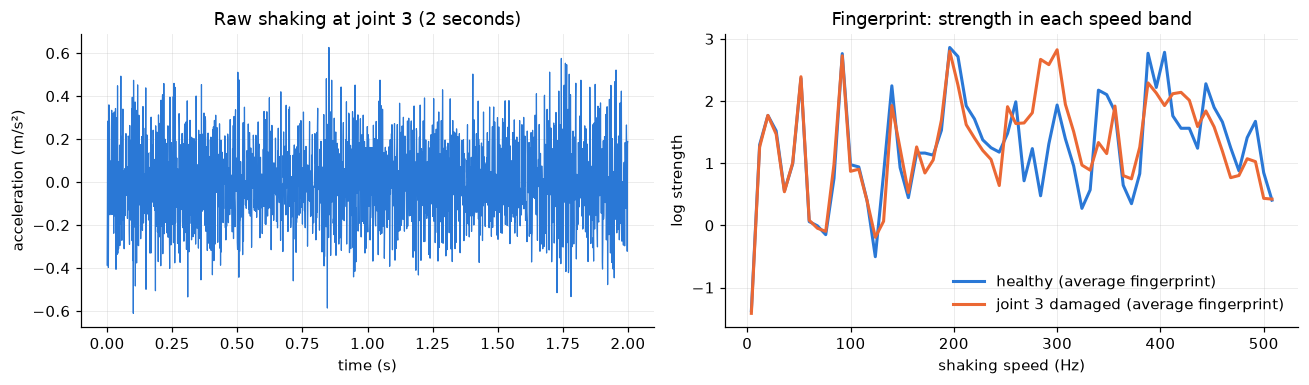

In [8]:
J = 3                      # joint used for the step-by-step walkthrough (sensor columns are 0-indexed)
FP = {k: fingerprints(d[:, J - 1]) for k, d in data.items()}
speeds = (np.arange(BANDS) + 0.5) * (FS / 2 / BANDS)

fig, ax = plt.subplots(1, 2, figsize=(12, 3.6))
t = np.arange(2 * FS) / FS
ax[0].plot(t, data["AU"][10 * FS:12 * FS, J - 1], color=BLUE, lw=0.8)
ax[0].set(title=f"Raw shaking at joint {J} (2 seconds)", xlabel="time (s)", ylabel="acceleration (m/s²)")
ax[1].plot(speeds, FP["AU"].mean(0), color=BLUE, label="healthy (average fingerprint)")
ax[1].plot(speeds, FP["BD3"].mean(0), color=ORANGE, label="joint 3 damaged (average fingerprint)")
ax[1].set(title="Fingerprint: strength in each speed band", xlabel="shaking speed (Hz)", ylabel="log strength")
ax[1].legend(frameon=False)
plt.tight_layout(); plt.savefig(FIG / "01_signal_and_fingerprint.png", dpi=160); plt.show()

## B2. Matrix representation
Healthy run A gives 254 one-second fingerprints. The first **70% (177 rows) are used to learn**; the last 30% are kept aside to set the alarm line.
**Rows = seconds, columns = speed bands.**

Learning matrix: 177 rows (seconds) × 64 columns (speed bands)
First 3 rows, first 8 columns:
 [[-1.836  0.772  1.481  0.991  0.676  1.119  2.822 -0.109]
 [-1.514  1.463  1.229  1.08   0.272  1.383  2.375  0.068]
 [-1.011  1.335  1.217  1.497  0.352  1.014  1.267 -0.14 ]]


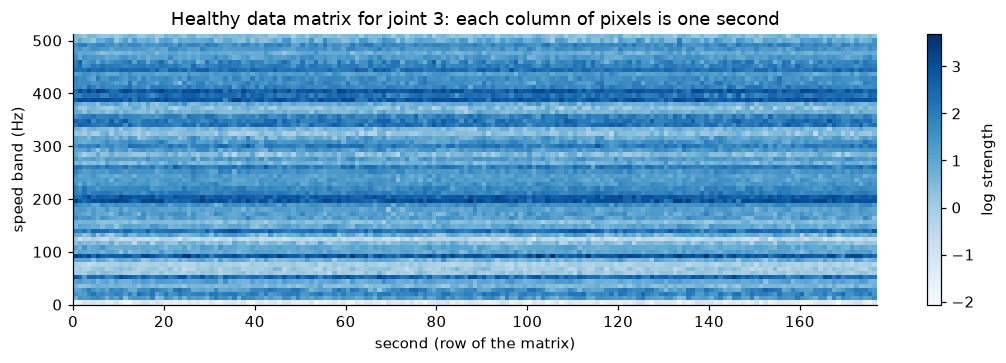

In [9]:
A_all = FP["AU"]
n_train = int(0.7 * len(A_all))
train, valid = A_all[:n_train], A_all[n_train:]
mu = train.mean(axis=0)
Xr = train - mu                                    # centred data matrix
print(f"Learning matrix: {train.shape[0]} rows (seconds) × {train.shape[1]} columns (speed bands)")
print("First 3 rows, first 8 columns:\n", train[:3, :8])

plt.figure(figsize=(10, 3.4))
plt.imshow(train.T, aspect="auto", origin="lower", cmap="Blues", extent=[0, n_train, 0, FS / 2])
plt.colorbar(label="log strength"); plt.grid(False)
plt.title(f"Healthy data matrix for joint {J}: each column of pixels is one second")
plt.xlabel("second (row of the matrix)"); plt.ylabel("speed band (Hz)")
plt.tight_layout(); plt.savefig(FIG / "02_data_matrix.png", dpi=160); plt.show()

## B3. Matrix simplification (RREF) and structure of the space
RREF of the real matrix finds which snapshots are independent (pivot columns). Rank and nullity describe the space the healthy data spans.

In [10]:
def rref(M, tol=1e-9):
    M = M.astype(float).copy(); rows, cols = M.shape; piv = []; r = 0
    for c in range(cols):
        if r == rows: break
        p = r + np.argmax(np.abs(M[r:, c]))
        if abs(M[p, c]) < tol: continue
        M[[r, p]] = M[[p, r]]; M[r] /= M[r, c]
        for i in range(rows):
            if i != r: M[i] -= M[i, c] * M[r]
        piv.append(c); r += 1
    return M, piv

K = 10                                     # number of patterns kept for the model (see B7)
S = Xr[:K].T                               # 64 × 10: first ten centred snapshots as columns
R_real, piv = rref(S)
print("RREF of [snapshot 1 ... snapshot 10] (first 10 rows shown):\n", R_real[:10])
print(f"Pivot columns: {piv}  → all {len(piv)} snapshots are linearly independent")

rank = np.linalg.matrix_rank(Xr)
print(f"\nFull learning matrix: rank = {rank}, nullity = {Xr.shape[1] - rank}")
print("Sensor noise makes every direction slightly used, so the plain rank is 'full'.")
print("Eigenvalues (B7) will tell us how many directions actually MATTER.")

RREF of [snapshot 1 ... snapshot 10] (first 10 rows shown):
 [[ 1.  0.  0.  0.  0.  0.  0.  0.  0.  0.]
 [ 0.  1.  0.  0.  0.  0.  0.  0.  0.  0.]
 [ 0.  0.  1.  0.  0.  0.  0.  0.  0.  0.]
 [ 0.  0.  0.  1.  0.  0.  0.  0.  0.  0.]
 [ 0.  0.  0.  0.  1.  0.  0.  0.  0.  0.]
 [ 0.  0.  0.  0.  0.  1.  0.  0.  0.  0.]
 [ 0.  0.  0.  0.  0.  0.  1.  0.  0.  0.]
 [ 0.  0.  0.  0.  0.  0.  0.  1.  0.  0.]
 [ 0.  0.  0.  0.  0.  0.  0.  0.  1.  0.]
 [-0. -0. -0. -0. -0. -0. -0. -0. -0.  1.]]
Pivot columns: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]  → all 10 snapshots are linearly independent

Full learning matrix: rank = 64, nullity = 0
Sensor noise makes every direction slightly used, so the plain rank is 'full'.
Eigenvalues (B7) will tell us how many directions actually MATTER.


## B4. Remove redundancy (basis selection)
We have 177 healthy snapshots, but they live in a 64-dimensional space, so at most 64 can be independent: the rest are combinations of others (redundant). We don't need all of them: we select a small **basis** that describes healthy vibration, starting with the independent snapshots RREF found.

In [11]:
n_snap = Xr.shape[0]
print(f"Snapshots: {n_snap}, independent at most: {rank}, redundant: {n_snap - rank}")
print(f"Candidate basis for our model: the {len(piv)} independent snapshots found by RREF (pivot columns).")
print("B7 will replace them with a better basis of the same size: the top eigenvectors.")

Snapshots: 177, independent at most: 64, redundant: 113
Candidate basis for our model: the 10 independent snapshots found by RREF (pivot columns).
B7 will replace them with a better basis of the same size: the top eigenvectors.


## B5. Orthogonalization (Gram–Schmidt)
Turn the 10 selected snapshots into 10 perpendicular unit vectors, an **orthonormal basis** of the same space.

In [12]:
def gram_schmidt_np(cols):
    Q = []
    for v in cols.T:
        w = v - sum((v @ q) * q for q in Q) if Q else v.copy()
        Q.append(w / np.linalg.norm(w))
    return np.array(Q).T

Q_naive = gram_schmidt_np(S)
print("QᵀQ (should be the identity matrix), top-left 4×4:\n", (Q_naive.T @ Q_naive)[:4, :4])
print("Max deviation from identity:", np.abs(Q_naive.T @ Q_naive - np.eye(K)).max().round(12))

QᵀQ (should be the identity matrix), top-left 4×4:
 [[ 1.  0.  0. -0.]
 [ 0.  1.  0. -0.]
 [ 0.  0.  1. -0.]
 [-0. -0. -0.  1.]]
Max deviation from identity: 0.0


## B6. Projection and least squares
Rebuild an unseen healthy second using the basis. The rebuild is the projection; the leftover is perpendicular to the basis, which is the least-squares condition.

In [13]:
x_new = valid[0] - mu
proj = Q_naive @ (Q_naive.T @ x_new)              # projection onto span(Q)
coef_ls, *_ = np.linalg.lstsq(S, x_new, rcond=None) # least squares with the ORIGINAL (non-orthogonal) snapshots
proj_ls = S @ coef_ls
left = x_new - proj
print(f"Projection vs least-squares rebuild, max difference: {np.abs(proj - proj_ls).max():.2e}  (same answer)")
print(f"Leftover · basis vectors (should be ~0): max {np.abs(Q_naive.T @ left).max():.2e}")
print(f"Share of this second explained by the basis: {1 - (left @ left) / (x_new @ x_new):.1%}")

Projection vs least-squares rebuild, max difference: 8.60e-16  (same answer)
Leftover · basis vectors (should be ~0): max 1.67e-16
Share of this second explained by the basis: 24.7%


## B7. Eigenvalues and eigenvectors: the *best* basis
Gram–Schmidt gave *a* basis, but not the best one. The eigenvectors of the covariance matrix give the directions in which healthy vibration actually varies most: the **eigen-vibrations**.

Top 10 eigenvalues: [0.326 0.258 0.244 0.227 0.212 0.177 0.175 0.166 0.154 0.139]
Share of variation in top 10 patterns: 41.3%

On unseen healthy seconds, variation captured by 10 vectors:
  Gram–Schmidt basis (from raw snapshots): 28.2%
  Eigenvector basis:                       32.9%   ← better with the same number of vectors


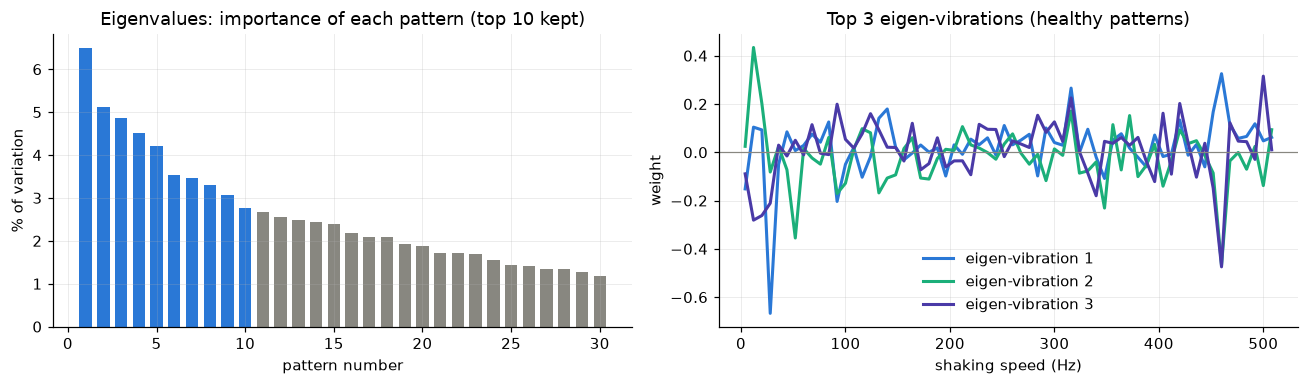

In [14]:
Cov = Xr.T @ Xr / (len(Xr) - 1)                    # 64 × 64, symmetric
evals, evecs = np.linalg.eigh(Cov)
order = np.argsort(evals)[::-1]; evals, evecs = evals[order], evecs[:, order]
P_eig = evecs[:, :K]
share = evals / evals.sum()
print("Top 10 eigenvalues:", evals[:10])
print(f"Share of variation in top {K} patterns: {share[:K].sum():.1%}")

def captured(Q, Z):
    C = Z - mu; return ((C @ Q) ** 2).sum() / (C ** 2).sum()
print(f"\nOn unseen healthy seconds, variation captured by {K} vectors:")
print(f"  Gram–Schmidt basis (from raw snapshots): {captured(Q_naive, valid):.1%}")
print(f"  Eigenvector basis:                       {captured(P_eig, valid):.1%}   ← better with the same number of vectors")

fig, ax = plt.subplots(1, 2, figsize=(12, 3.6))
ax[0].bar(np.arange(1, 31), share[:30] * 100, color=[BLUE] * K + [GREY] * 20, width=0.7)
ax[0].set(title=f"Eigenvalues: importance of each pattern (top {K} kept)", xlabel="pattern number", ylabel="% of variation")
for i, c in enumerate(["#2a78d6", "#1baf7a", "#4a3aa7"]):
    ax[1].plot(speeds, evecs[:, i], color=c, label=f"eigen-vibration {i + 1}")
ax[1].axhline(0, color=GREY, lw=0.8)
ax[1].set(title="Top 3 eigen-vibrations (healthy patterns)", xlabel="shaking speed (Hz)", ylabel="weight")
ax[1].legend(frameon=False)
plt.tight_layout(); plt.savefig(FIG / "03_eigenvalues_and_patterns.png", dpi=160); plt.show()

## B8. Diagonalization of the symmetric matrix
Because the covariance matrix is symmetric, **Vᵀ·Cov·V is diagonal**: in eigenvector coordinates the patterns are completely independent (uncorrelated), and each diagonal entry is a pattern's importance.

In [15]:
Dg = evecs.T @ Cov @ evecs
off = Dg - np.diag(np.diag(Dg))
print("Vᵀ Cov V, top-left 4×4:\n", Dg[:4, :4])
print(f"Largest off-diagonal entry: {np.abs(off).max():.1e}   (diagonal entries up to {Dg.max():.3f})")

Vᵀ Cov V, top-left 4×4:
 [[ 0.326  0.    -0.     0.   ]
 [ 0.     0.258 -0.     0.   ]
 [-0.    -0.     0.244  0.   ]
 [ 0.     0.     0.     0.227]]
Largest off-diagonal entry: 1.8e-16   (diagonal entries up to 0.326)


## B9. Final output: the damage detector (joint 3)
For any new second: centre it, **project onto the top-10 eigen-vibrations**, and measure the **leftover length** = error score.
Alarm line = 99th percentile of the error on the held-out healthy seconds from run A.

Alarm line: 2.292

recording                     median score   seconds flagged
healthy (unseen run B)               1.751             0.8%
damage at joint 3                    4.059           100.0%
damage at joint 13                   4.023           100.0%
damage at joint 26                   2.731            96.1%


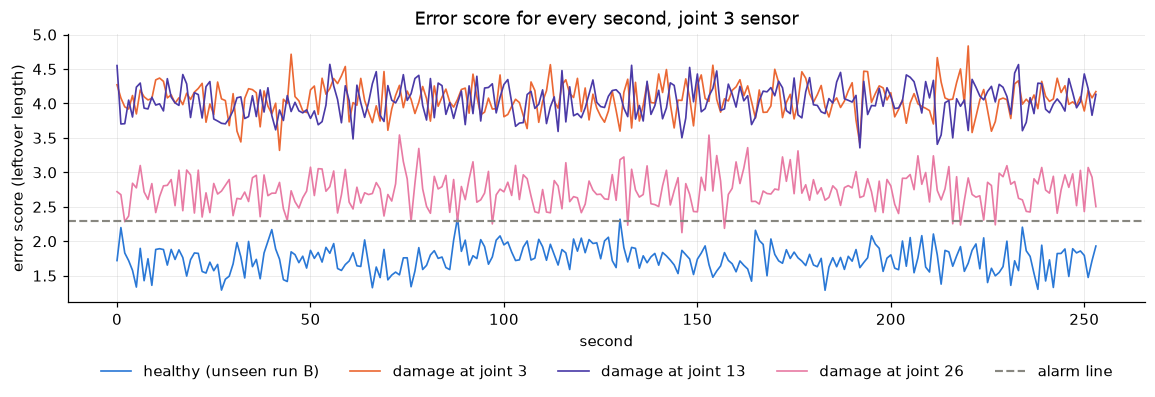

In [16]:
def score(Z, P=P_eig, m=mu):
    C = Z - m
    return np.linalg.norm(C - (C @ P) @ P.T, axis=1)

thr = np.percentile(score(valid), 99)
cases = [("BU", "healthy (unseen run B)"), ("BD3", "damage at joint 3"), ("BD13", "damage at joint 13"), ("BD26", "damage at joint 26")]
print(f"Alarm line: {thr:.3f}\n")
print(f"{'recording':28s}{'median score':>14s}{'seconds flagged':>18s}")
for k, label in cases:
    e = score(FP[k]); print(f"{label:28s}{np.median(e):14.3f}{(e > thr).mean():17.1%}")

fig, ax = plt.subplots(figsize=(11, 3.8))
CASE_COLOURS = {"BU": BLUE, "BD3": ORANGE, "BD13": "#4a3aa7", "BD26": "#e87ba4"}
for k, label in cases:
    e = score(FP[k])
    ax.plot(e, color=CASE_COLOURS[k], lw=1.1, label=label)
ax.axhline(thr, color=GREY, ls="--", lw=1.4, label="alarm line")
ax.set(title=f"Error score for every second, joint {J} sensor", xlabel="second", ylabel="error score (leftover length)")
ax.legend(frameon=False, ncol=5, loc="upper center", bbox_to_anchor=(0.5, -0.18))
plt.tight_layout(); plt.savefig(FIG / "04_scores_joint3.png", dpi=160, bbox_inches="tight"); plt.show()

## B10. All 30 sensors: is the structure damaged, and where?
We repeat B2–B9 for every sensor (each gets its own healthy model and alarm line).

In [17]:
names = ["BU", "BD3", "BD13", "BD26"]
flagged = {k: np.zeros(30) for k in names}
level = {k: np.zeros(30) for k in names}
for j in range(30):
    fp = {k: fingerprints(d[:, j]) for k, d in data.items()}
    tr, va = fp["AU"][:n_train], fp["AU"][n_train:]
    m = tr.mean(0); Xj = tr - m
    w, V = np.linalg.eigh(Xj.T @ Xj / (len(Xj) - 1)); Pj = V[:, np.argsort(w)[::-1][:K]]
    tj = np.percentile(score(va, Pj, m), 99)
    for k in names:
        e = score(fp[k], Pj, m)
        flagged[k][j] = (e > tj).mean()
        level[k][j] = e.mean() / tj           # average score relative to that sensor's alarm line

summary = pd.DataFrame({
    "recording": ["healthy, unseen (BU)", "damage at joint 3", "damage at joint 13", "damage at joint 26"],
    "avg % of seconds flagged (30 sensors)": [f"{flagged[k].mean():.1%}" for k in names],
    "sensors that raise the alarm (>50% flagged)": [int((flagged[k] > 0.5).sum()) for k in names],
    "verdict": ["HEALTHY" if (flagged[k] > 0.5).sum() < 15 else "DAMAGED" for k in names],
    "joint with highest score": [int(np.argmax(level[k])) + 1 for k in names],
})
summary

,recording,avg % of seconds flagged (30 sensors),sensors that raise the alarm (>50% flagged),verdict,joint with highest score
0,"healthy, unseen (BU)",0.4%,0,HEALTHY,1
1,damage at joint 3,99.9%,30,DAMAGED,3
2,damage at joint 13,99.9%,30,DAMAGED,3
3,damage at joint 26,99.1%,30,DAMAGED,26


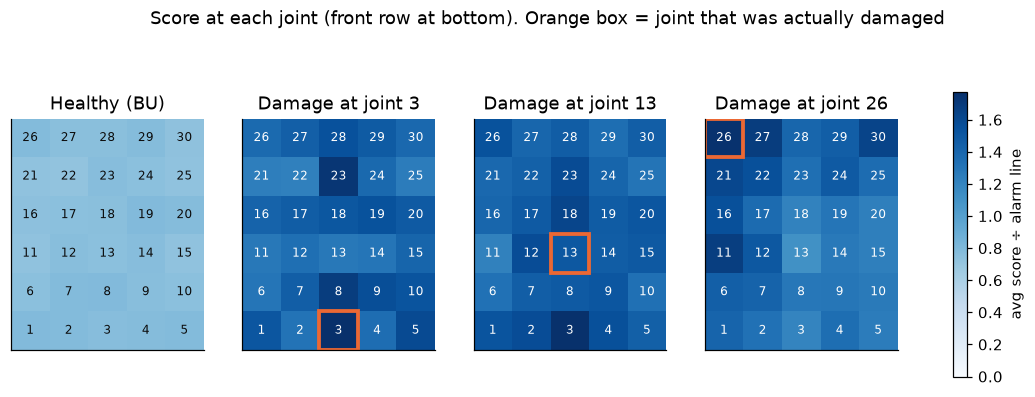

In [18]:
fig, axes = plt.subplots(1, 4, figsize=(13, 4.2))
vmax = max(level[k].max() for k in names)
for ax, k, title in zip(axes, names, ["Healthy (BU)", "Damage at joint 3", "Damage at joint 13", "Damage at joint 26"]):
    grid = level[k].reshape(6, 5)               # joints 1–5 = front row ... 26–30 = back row
    im = ax.imshow(grid, cmap="Blues", vmin=0, vmax=vmax, origin="lower")
    for idx in range(30):
        r, c = divmod(idx, 5)
        ax.text(c, r, idx + 1, ha="center", va="center", fontsize=8,
                color="white" if grid[r, c] > 0.6 * vmax else "#0b0b0b")
    if k != "BU":
        tj = int(k[2:]) - 1; r, c = divmod(tj, 5)
        ax.add_patch(plt.Rectangle((c - 0.5, r - 0.5), 1, 1, fill=False, ec=ORANGE, lw=2.5))
    ax.set_title(title); ax.set_xticks([]); ax.set_yticks([]); ax.grid(False)
fig.colorbar(im, ax=axes, shrink=0.8, label="avg score ÷ alarm line")
fig.suptitle("Score at each joint (front row at bottom). Orange box = joint that was actually damaged", y=0.98)
plt.savefig(FIG / "05_joint_map.png", dpi=160, bbox_inches="tight"); plt.show()

**Reading the results honestly**
* **Detection works very well:** on the unseen healthy run almost no seconds are flagged, while for all three damage cases nearly every second on nearly every sensor is flagged.
* **Locating the damage is only indicative:** a loosened bolt changes how the *whole* frame vibrates, so all sensors react. The highest-scoring joint matches the damaged joint in some cases and sits near it in others, but the differences between joints are small. A dedicated localisation method would be future work.

---
## Summary: Concept → Purpose → Outcome

In [19]:
rows = [
 ("Matrix representation", "Hold healthy fingerprints as data", f"{train.shape[0]}×{train.shape[1]} matrix per sensor (seconds × speed bands)"),
 ("RREF", "Find independent snapshots", f"Pivots in all {len(piv)} columns → 10 independent snapshots"),
 ("Rank & nullity", "Describe the healthy space", f"rank {rank}, nullity {Xr.shape[1]-rank}: noise touches every direction"),
 ("Basis selection", "Remove redundancy", f"{Xr.shape[0]} snapshots but only {rank} independent; keep a basis of {K}"),
 ("Gram–Schmidt", "Orthonormal basis", "QᵀQ = I (perpendicular unit vectors)"),
 ("Projection", "Rebuild new data from healthy patterns", "Leftover = part healthy patterns can't explain"),
 ("Least squares", "Closest possible rebuild", "Same answer as projection; leftover ⟂ basis"),
 ("Eigenvalues/vectors", "Find the best patterns", f"Top {K} eigen-vibrations capture {captured(P_eig, valid):.0%} vs {captured(Q_naive, valid):.0%} for Gram–Schmidt basis"),
 ("Diagonalization", "Make patterns independent", f"VᵀCV diagonal (off-diagonal ≤ {np.abs(off).max():.0e})"),
 ("Final output", "Damage detection", f"Healthy: {flagged['BU'].mean():.1%} flagged; damaged: {min(flagged[k].mean() for k in names[1:]):.0%}+ flagged"),
]
pd.DataFrame(rows, columns=["Concept", "Purpose", "Outcome on our data"])

,Concept,Purpose,Outcome on our data
0,Matrix representation,Hold healthy fingerprints as data,177×64 matrix per sensor (seconds × speed bands)
1,RREF,Find independent snapshots,Pivots in all 10 columns → 10 independent snap...
2,Rank & nullity,Describe the healthy space,"rank 64, nullity 0: noise touches every direction"
3,Basis selection,Remove redundancy,177 snapshots but only 64 independent; keep a ...
4,Gram–Schmidt,Orthonormal basis,QᵀQ = I (perpendicular unit vectors)
5,Projection,Rebuild new data from healthy patterns,Leftover = part healthy patterns can't explain
6,Least squares,Closest possible rebuild,Same answer as projection; leftover ⟂ basis
7,Eigenvalues/vectors,Find the best patterns,Top 10 eigen-vibrations capture 33% vs 28% for...
8,Diagonalization,Make patterns independent,VᵀCV diagonal (off-diagonal ≤ 2e-16)
9,Final output,Damage detection,Healthy: 0.4% flagged; damaged: 99%+ flagged
